In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

In [ ]:
'''# CLEAR TABLE if needed

conn = sqlite3.connect('../data ingestion mvp/taiwan_housing.db')
cursor = conn.cursor()

cursor.execute('DROP TABLE IF EXISTS transactions;')
conn.commit()

conn.close()'''

In [2]:
def load_data():
    with sqlite3.connect('../data ingestion mvp/taiwan_housing.db') as conn:
        return pd.read_sql(
            'SELECT * FROM transactions', 
            conn,
            parse_dates=['date']
        )
    
df = load_data()
df.head()

,date,address,price,area,price_per_sqm,building_type,district,computed_price_per_sqm,price_diff
0,2026-03-03,臺北市文山區木柵路三段８５巷８弄３號十樓,30000000,120.40,249169.0,住宅大樓(11層含以上有電梯),文山區,249169.0,0.0
1,2026-03-02,臺北市北投區裕民二路６７號三樓,30900000,101.15,305487.0,住宅大樓(11層含以上有電梯),北投區,305487.0,0.0
2,2026-03-01,臺北市中正區南海路１０７號三樓之６,6500000,35.67,182226.0,華廈(10層含以下有電梯),中正區,182226.0,0.0
3,2026-03-03,臺北市萬華區華西街１７之４號五樓之５,5150000,32.32,159344.0,華廈(10層含以下有電梯),萬華區,159344.0,0.0
4,2026-03-04,臺北市大安區光復南路６９６之３號,1860000,4.05,NaN,其他,大安區,459259.0,NaN


In [3]:
df.shape

(663, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 663 entries, 0 to 662
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    663 non-null    datetime64[ns]
 1   address                 663 non-null    object        
 2   price                   663 non-null    int64         
 3   area                    663 non-null    float64       
 4   price_per_sqm           632 non-null    float64       
 5   building_type           663 non-null    object        
 6   district                663 non-null    object        
 7   computed_price_per_sqm  663 non-null    float64       
 8   price_diff              632 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(3)
memory usage: 46.7+ KB


In [5]:
df.describe()

,date,price,area,price_per_sqm,computed_price_per_sqm,price_diff
count,663,6.630000e+02,663.000000,6.320000e+02,6.630000e+02,632.000000
mean,2025-04-01 05:01:54.027149312,2.955502e+07,121.738552,2.625095e+05,2.402736e+05,16269.487342
min,2020-02-25 00:00:00,5.020930e+05,1.520000,3.013800e+04,2.499300e+04,0.000000
25%,2025-10-25 00:00:00,1.417000e+07,66.805000,1.917070e+05,1.791200e+05,0.000000
50%,2025-12-31 00:00:00,2.323000e+07,106.870000,2.468085e+05,2.249350e+05,0.000000
75%,2026-01-21 00:00:00,3.640000e+07,147.995000,3.104940e+05,2.846080e+05,30469.000000
max,2026-03-10 00:00:00,2.440000e+08,822.970000,2.885951e+06,2.885951e+06,177211.000000
std,NaN,2.647106e+07,90.228189,1.420034e+05,1.416251e+05,28469.670912


In [6]:
df.isna().sum()

date                       0
address                    0
price                      0
area                       0
price_per_sqm             31
building_type              0
district                   0
computed_price_per_sqm     0
price_diff                31
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df[df['price_per_sqm'].isna()].head()

,date,address,price,area,price_per_sqm,building_type,district,computed_price_per_sqm,price_diff
4,2026-03-04,臺北市大安區光復南路６９６之３號,1860000,4.05,NaN,其他,大安區,459259.0,NaN
22,2026-03-04,臺北市中山區雙城街１９巷８號地下四層,960000,38.41,NaN,其他,中山區,24993.0,NaN
23,2026-03-07,臺北市南港區永吉路５５３巷７之１號,3500000,26.05,NaN,其他,南港區,134357.0,NaN
32,2026-02-25,臺北市南港區中坡南路４９巷１號、３號、５號、７號、７之１號門牌房屋地下一層至地下三層,2700000,40.30,NaN,其他,南港區,66998.0,NaN
34,2026-02-27,臺北市北投區泉源路１８之１號,2250000,41.44,NaN,其他,北投區,54295.0,NaN


In [9]:
print(f'Start: {df['date'].min()}')
print(f'Start: {df['date'].max()}')

Start: 2020-02-25 00:00:00
Start: 2026-03-10 00:00:00


# Date inspection

In [10]:
df[df['date'].dt.year == 2020]

,date,address,price,area,price_per_sqm,building_type,district,computed_price_per_sqm,price_diff
660,2020-11-16,臺北市信義區松德路１６９巷２６號三樓,66800000,247.91,328864.0,住宅大樓(11層含以上有電梯),信義區,269453.0,59411.0
661,2020-07-30,臺北市信義區松德路１６９巷２０號十八樓,81700000,296.48,359870.0,住宅大樓(11層含以上有電梯),信義區,275567.0,84303.0
662,2020-02-25,臺北市中正區三元街８５號十九樓之３,44940000,191.00,273451.0,住宅大樓(11層含以上有電梯),中正區,235288.0,38163.0


In [11]:
df[df['date'].dt.year == 2026].head()

,date,address,price,area,price_per_sqm,building_type,district,computed_price_per_sqm,price_diff
0,2026-03-03,臺北市文山區木柵路三段８５巷８弄３號十樓,30000000,120.40,249169.0,住宅大樓(11層含以上有電梯),文山區,249169.0,0.0
1,2026-03-02,臺北市北投區裕民二路６７號三樓,30900000,101.15,305487.0,住宅大樓(11層含以上有電梯),北投區,305487.0,0.0
2,2026-03-01,臺北市中正區南海路１０７號三樓之６,6500000,35.67,182226.0,華廈(10層含以下有電梯),中正區,182226.0,0.0
3,2026-03-03,臺北市萬華區華西街１７之４號五樓之５,5150000,32.32,159344.0,華廈(10層含以下有電梯),萬華區,159344.0,0.0
4,2026-03-04,臺北市大安區光復南路６９６之３號,1860000,4.05,NaN,其他,大安區,459259.0,NaN


In [12]:
df['date'].dt.year.value_counts().sort_index()

date
2020      3
2021     73
2022     29
2023     17
2024     11
2025    203
2026    327
Name: count, dtype: int64

<Axes: xlabel='date'>

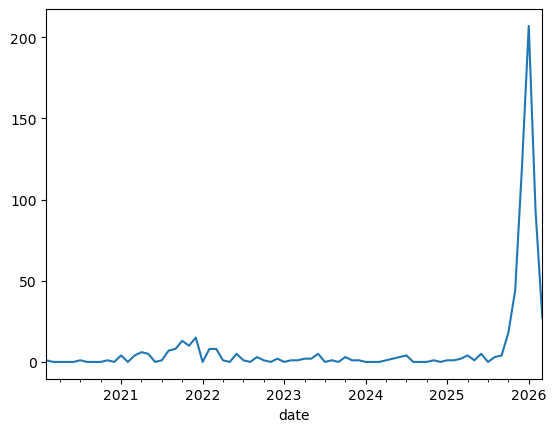

In [13]:
df.set_index('date').resample('ME').size().plot()

In [14]:
df.groupby(df['date'].dt.year).agg({
    'price':'mean',
    'area':'mean',
    'computed_price_per_sqm':'mean'
})

,price,area,computed_price_per_sqm
date,,,
2020,6.448000e+07,245.130000,260102.666667
2021,4.138986e+07,141.921233,295128.780822
2022,3.188828e+07,143.428966,226227.931034
2023,4.600235e+07,164.287059,274626.294118
2024,3.468564e+07,103.619091,362831.363636
2025,3.177975e+07,128.029113,250457.182266
2026,2.397689e+07,108.669664,216860.853211


### Date has as range of 2020 to 2026. the earlier years have a tiny sample size, with a large avereage area which are likely just a few large properties.
### The older records are likely due to delayed registrations, data corrections, etc.
### For modeling purposes, we will focus on records from 2026.

In [15]:
df_mvp = df[df['date'].dt.year == 2026]

# Variable distributions

Text(0.5, 1.0, 'Price Distribution')

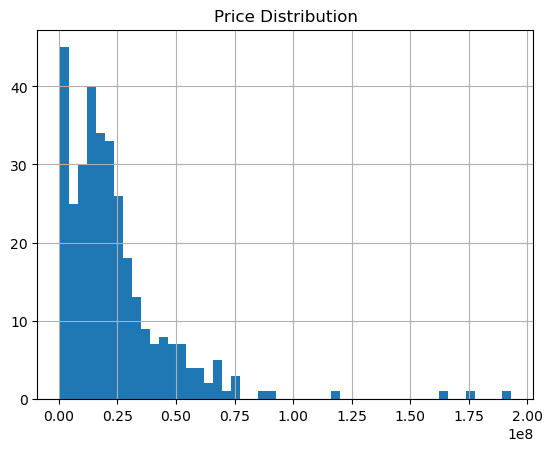

In [16]:
df_mvp['price'].hist(bins=50)
plt.title('Price Distribution')


Text(0.5, 1.0, 'Area Distribution')

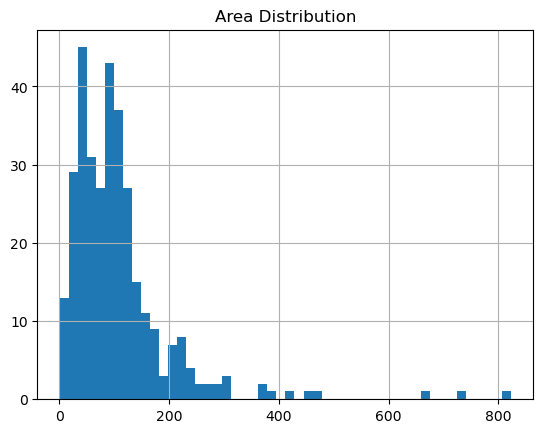

In [17]:
df_mvp['area'].hist(bins=50)
plt.title('Area Distribution')

Text(0.5, 1.0, 'Computed Price per Sqm')

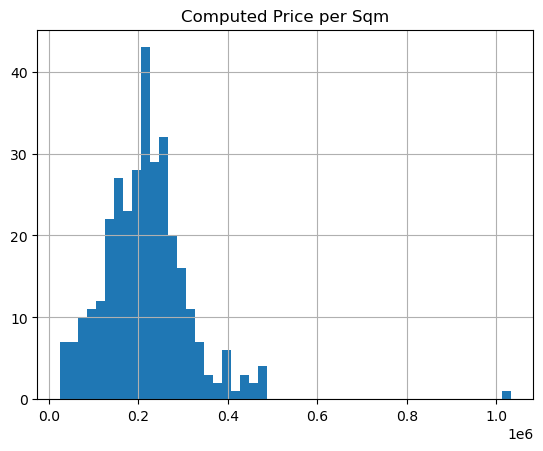

In [18]:
df_mvp['computed_price_per_sqm'].hist(bins=50)
plt.title('Computed Price per Sqm')

### From the distributions, price, area, and price per sqm all have extreme values.
### These could be 
- luxury properties
- bulk transactions
- mixed-used buildings
### Therefore, we do not remove them immediately.
### We will create a filtered view

In [19]:
df_mvp_filtered = df_mvp[df_mvp['price'] < df_mvp['price'].quantile(0.99)]

Text(0.5, 1.0, 'Price Distribution (after removing price extremes)')

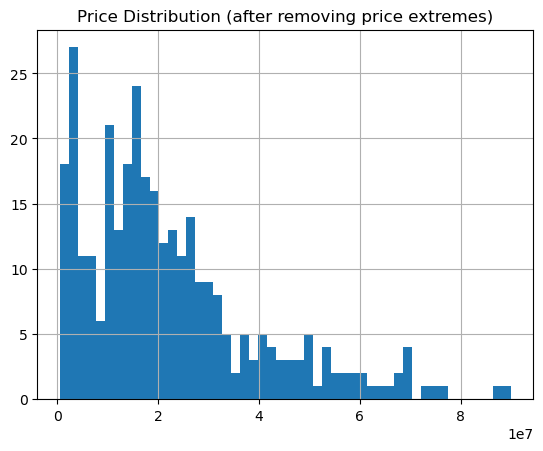

In [20]:
df_mvp_filtered['price'].hist(bins=50)
plt.title('Price Distribution (after removing price extremes)')

Text(0.5, 1.0, 'Area Distribution (after removing price extremes)')

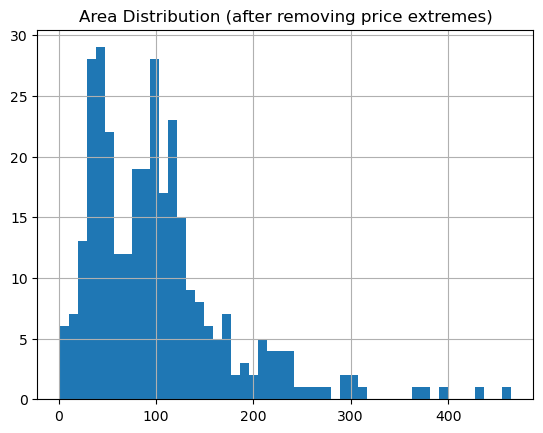

In [21]:
df_mvp_filtered['area'].hist(bins=50)
plt.title('Area Distribution (after removing price extremes)')

# variable relationships

Text(0.5, 1.0, 'price vs area')

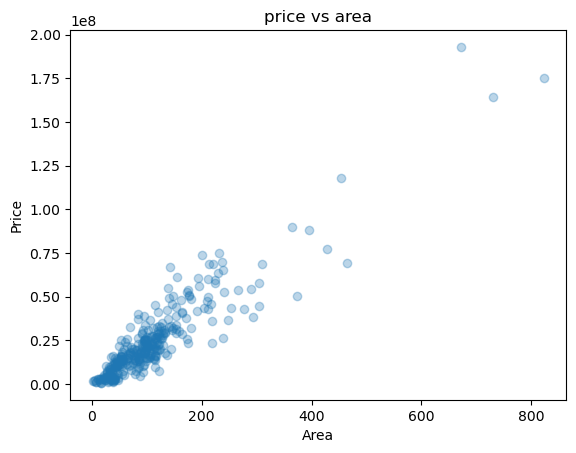

In [49]:
plt.scatter(df_mvp['area'], df_mvp['price'], alpha=0.3)
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('price vs area')

Text(0.5, 1.0, 'After removing price extremes')

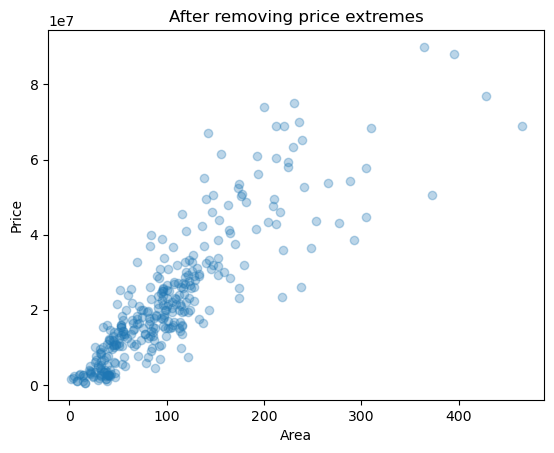

In [25]:
plt.scatter(df_mvp_filtered['area'], df_mvp_filtered['price'], alpha=0.3)
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('After removing price extremes')

Text(0, 0.5, 'computed price per sqm')

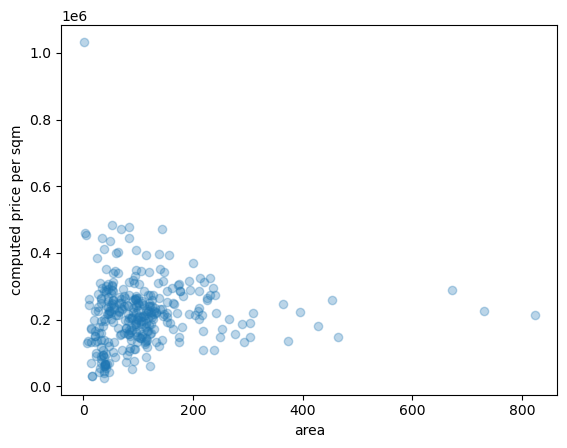

In [23]:
plt.scatter(df_mvp['area'], df_mvp['computed_price_per_sqm'], alpha=0.3)
plt.xlabel('area')
plt.ylabel('computed price per sqm')

In [24]:
df_mvp[['price', 'area', 'computed_price_per_sqm']].corr()

,price,area,computed_price_per_sqm
price,1.000000,0.921536,0.305028
area,0.921536,1.000000,0.042858
computed_price_per_sqm,0.305028,0.042858,1.000000


### Based on the plots and correlations, 
- There is a strong positive relationship between `area` and `price`
- The spread of `price` increases with `area`, suggesting that other factors also significantly influence pricing
- Relationship between `area` and `price_per_sqm` is weak, but expected since `price_per_sqm` is derived from price over area.
- Variation in `price_per_sqm` likely reflects differences in property quality, district, or transaction conditions rather than size alone.

# Inspect `price per sqm` and computed version

Text(0.5, 1.0, 'price differences distribution')

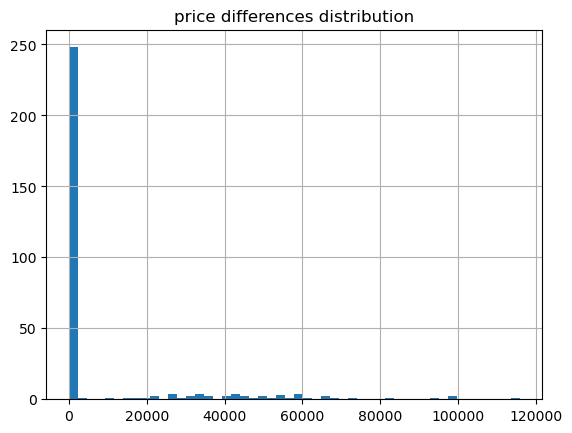

In [26]:
df_mvp['price_diff'].hist(bins=50)
plt.title('price differences distribution')

Text(0.5, 1.0, 'non-zero differences')

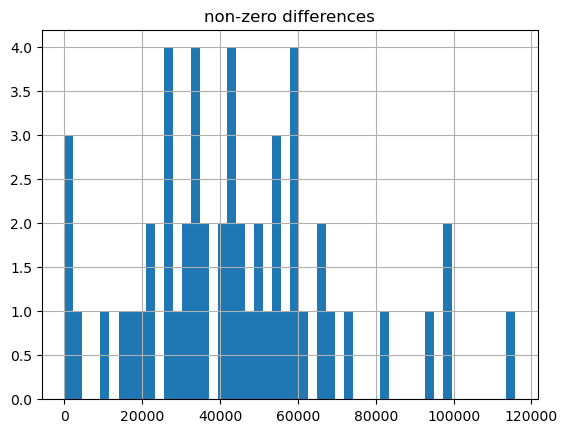

In [27]:
df_mvp[df_mvp['price_diff'] > 0]['price_diff'].hist(bins=50)
plt.title('non-zero differences')

In [28]:
df_mvp.sort_values('price_diff', ascending=False).head(10)

,date,address,price,area,price_per_sqm,building_type,district,computed_price_per_sqm,price_diff
192,2026-01-10,臺北市北投區致遠一路一段４０號十一樓,31530000,152.43,322702.0,住宅大樓(11層含以上有電梯),北投區,206849.0,115853.0
30,2026-02-26,臺北市中山區明水路３６７號十六樓之２,55000000,138.42,496146.0,住宅大樓(11層含以上有電梯),中山區,397341.0,98805.0
60,2026-02-01,臺北市信義區永吉路３０巷１０１弄２９號四樓,69880000,236.07,394540.0,住宅大樓(11層含以上有電梯),信義區,296014.0,98526.0
306,2026-01-07,臺北市中正區丹陽街３３號八樓,61470000,155.65,488652.0,住宅大樓(11層含以上有電梯),中正區,394925.0,93727.0
285,2026-01-17,臺北市中山區新生北路二段６８巷８號六樓之６,25750000,124.83,288897.0,住宅大樓(11層含以上有電梯),中山區,206281.0,82616.0
223,2026-01-03,臺北市中山區中山北路二段２７巷７號三樓,60880000,193.09,387991.0,住宅大樓(11層含以上有電梯),中山區,315293.0,72698.0
301,2026-01-01,臺北市文山區萬芳路８之１１號九樓,28800000,119.12,311010.0,住宅大樓(11層含以上有電梯),文山區,241773.0,69237.0
260,2026-01-11,臺北市內湖區金湖路６５巷１１號二樓之１,29580000,133.46,288286.0,住宅大樓(11層含以上有電梯),內湖區,221639.0,66647.0
207,2026-01-09,臺北市北投區三合街一段３８號八樓之２,33800000,153.25,285767.0,華廈(10層含以下有電梯),北投區,220555.0,65212.0
162,2026-01-08,臺北市北投區石牌路一段１６６巷２５號五樓之３,52500000,173.33,363783.0,住宅大樓(11層含以上有電梯),北投區,302890.0,60893.0


In [29]:
df_mvp.groupby('building_type')['price_diff'].mean().sort_values()

building_type
透天厝                    0.000000
公寓(5樓含以下無電梯)           0.364865
華廈(10層含以下有電梯)       5005.400000
住宅大樓(11層含以上有電梯)    14861.472868
其他                          NaN
Name: price_diff, dtype: float64

### `price_per_sqm` seems to be inconsistently defined across building types
### For low-rise (透天厝) / simple properties (公寓(5樓含以下無電梯)), there is almost no discrepency
- likely due to no shared facilities and no bundled components like parking
### For Mid-high rise buildings (華廈 / 住宅大樓), the higher the building complexity, the larger price differences. 
- strong signal that parking space is included in total price, but excluded from `area` used in `price_per_sqm`

### TODO

In [30]:
import sys
import os
sys.path.append(os.path.abspath('../data ingestion mvp'))

from ingestion import fetch_data

In [31]:
raw_df = fetch_data()
raw_df.columns

Status Code: 200
Content-Type: application/octet-stream
['a_lvr_land_a.csv', 'a_lvr_land_a_build.csv', 'a_lvr_land_a_land.csv', 'a_lvr_land_a_park.csv', 'a_lvr_land_b.csv']


Index(['鄉鎮市區', '交易標的', '土地位置建物門牌', '土地移轉總面積平方公尺', '都市土地使用分區', '非都市土地使用分區',
       '非都市土地使用編定', '交易年月日', '交易筆棟數', '移轉層次', '總樓層數', '建物型態', '主要用途', '主要建材',
       '建築完成年月', '建物移轉總面積平方公尺', '建物現況格局-房', '建物現況格局-廳', '建物現況格局-衛',
       '建物現況格局-隔間', '有無管理組織', '總價元', '單價元平方公尺', '車位類別', '車位移轉總面積平方公尺', '車位總價元',
       '備註', '編號', '主建物面積', '附屬建物面積', '陽台面積', '電梯', '移轉編號'],
      dtype='object')

In [32]:
raw_df = raw_df.iloc[1:].reset_index(drop=True)
raw_df = raw_df[['交易年月日', '土地位置建物門牌', '總價元',
        '建物移轉總面積平方公尺', '單價元平方公尺',
        '建物型態', '鄉鎮市區','車位總價元',
        '車位移轉總面積平方公尺']]
raw_df = raw_df.rename(columns={
        "交易年月日": "date",
        "土地位置建物門牌": "address",
        "總價元": "price",
        "建物移轉總面積平方公尺": "area",
        "單價元平方公尺": "price_per_sqm", # contains missing value
        "建物型態": "building_type",
        "鄉鎮市區": "district",
        '車位總價元':'parking_price',
        '車位移轉總面積平方公尺':'parking_area'
    })

# Handle weird numeric values
raw_df['price'] = raw_df['price'].astype(str).str.replace(',','')
raw_df['area'] = raw_df['area'].astype(str).str.replace(',','')
raw_df['parking_price'] = raw_df['parking_price'].astype(str).str.replace(',','')
raw_df['parking_area'] = raw_df['parking_area'].astype(str).str.replace(',','')

# Convert numeric fields
raw_df['price'] = pd.to_numeric(raw_df['price'], errors='coerce')
raw_df['area'] = pd.to_numeric(raw_df['area'], errors='coerce')
raw_df['parking_price'] = pd.to_numeric(raw_df['parking_price'], errors='coerce')
raw_df['parking_area'] = pd.to_numeric(raw_df['parking_area'], errors='coerce')
raw_df['price_per_sqm'] = pd.to_numeric(raw_df['price_per_sqm'], errors='coerce')

raw_df = raw_df[raw_df['price'] > 0]
raw_df = raw_df[raw_df['area'] > 0]

raw_df['computed_price_per_sqm'] = (raw_df['price'] / raw_df['area']).round()
raw_df['price_diff'] = abs(raw_df['computed_price_per_sqm'] - raw_df['price_per_sqm'])
raw_df['adj_price'] = raw_df['price'] - raw_df['parking_price'].fillna(0)
raw_df['adj_area'] = raw_df['area'] - raw_df['parking_area'].fillna(0)
raw_df['adj_price_per_sqm'] = (raw_df['adj_price'] / raw_df['adj_area']).round()
raw_df['adj_diff'] = abs(raw_df['adj_price_per_sqm'] - raw_df['price_per_sqm'])

In [33]:
raw_df[['price_diff', 'adj_diff']].describe()

,price_diff,adj_diff
count,633.000000,633.000000
mean,16243.785150,2355.819905
std,28454.487371,10981.053729
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,30361.000000,0.000000
max,177211.000000,97688.000000


### After performing a quick experiment by including the parking prices and area in the raw dataset, we observed a huge drop in the price differences.
### We conclude that parking explains most discrepancies, but not all.
### We will update this change to the ingestion pipeline.

# Location Analysis

In [36]:
df_mvp['district'].value_counts().head(10)

district
中山區    49
內湖區    40
大安區    32
文山區    31
士林區    29
北投區    27
松山區    26
中正區    23
信義區    19
萬華區    18
Name: count, dtype: int64

In [37]:
df_mvp.groupby('district')['computed_price_per_sqm'].mean().sort_values(ascending=False).head(10)

district
中正區    302124.608696
大安區    267684.531250
信義區    249454.368421
中山區    236948.836735
松山區    235431.076923
大同區    201494.000000
北投區    196215.740741
士林區    190744.137931
內湖區    187975.900000
萬華區    179618.833333
Name: computed_price_per_sqm, dtype: float64

# Analyzing different building types

In [43]:
df_mvp.groupby('building_type')['computed_price_per_sqm'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)

,mean,median,count
building_type,,,
住宅大樓(11層含以上有電梯),251911.852713,245294.0,129
華廈(10層含以下有電梯),219991.105882,217408.0,85
公寓(5樓含以下無電梯),195063.094595,192483.0,74
透天厝,177548.200000,141431.5,10
其他,120947.413793,68449.0,29


### It seems like there is a relationship between different building types and `price_per_sqm`
### However, since the data is imbalanced, we cannot conclude anything just from this observation.

# Handle skew

C:\Users\User\AppData\Local\Temp\ipykernel_34160\1744315029.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mvp['log_price'] = np.log1p(df_mvp['price'])


Text(0.5, 1.0, 'Log Price Distribution')

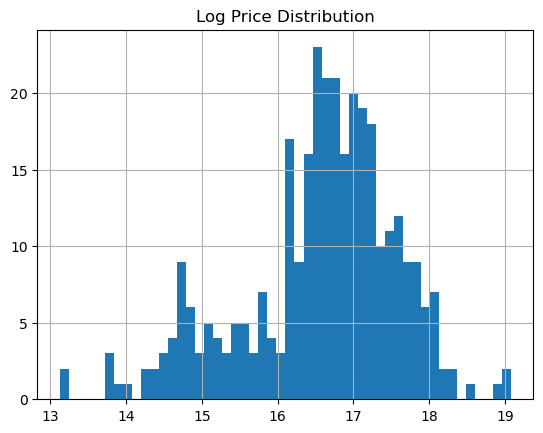

In [44]:
df_mvp['log_price'] = np.log1p(df_mvp['price'])
df_mvp['log_price'].hist(bins=50)
plt.title('Log Price Distribution')

C:\Users\User\AppData\Local\Temp\ipykernel_34160\2575535796.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mvp['log_area'] = np.log1p(df_mvp['area'])


Text(0.5, 1.0, 'Log Price Distribution')

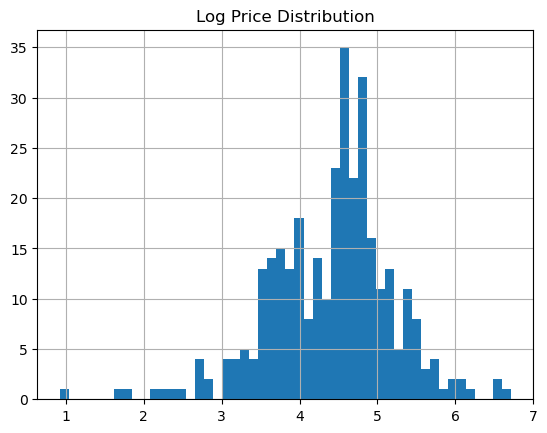

In [45]:
df_mvp['log_area'] = np.log1p(df_mvp['area'])
df_mvp['log_area'].hist(bins=50)
plt.title('Log Area Distribution')

Text(0.5, 1.0, 'log price vs log area')

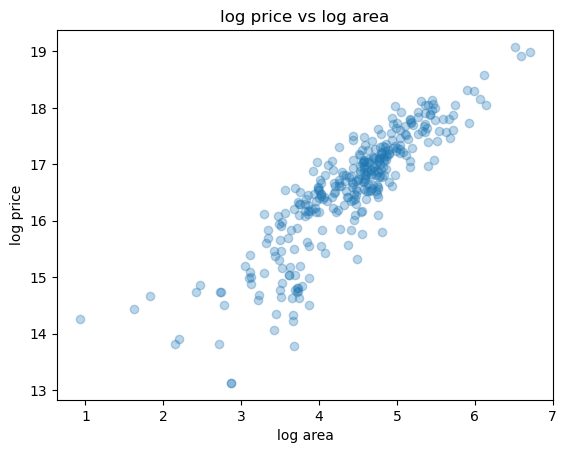

In [50]:
plt.scatter(df_mvp['log_area'], df_mvp['log_price'], alpha=0.3)
plt.xlabel('log area')
plt.ylabel('log price')
plt.title('log price vs log area')

Text(0.5, 1.0, 'log price vs area')

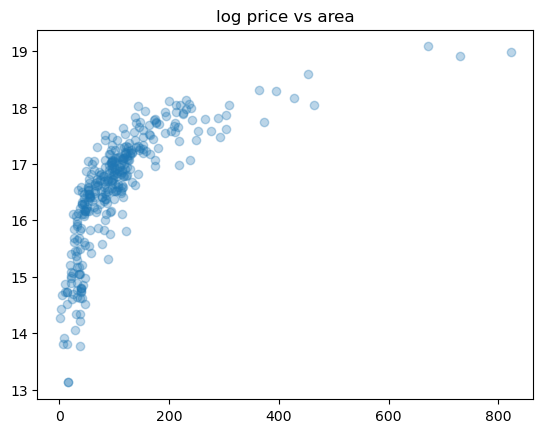

In [48]:
plt.scatter(df_mvp['area'], df_mvp['log_price'], alpha=0.3)
plt.title('log price vs area')